In [ ]:
import yfinance as yf
df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")
df.head()

/tmp/ipykernel_216/2076617418.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-02-10,77.694817,77.694817,75.834301,75.914035,109348800
2020-02-11,77.226082,78.262659,77.008620,78.190175,94323200
2020-02-12,79.060005,79.064835,77.675486,77.675486,113730400
2020-02-13,78.497017,78.823213,78.129748,78.332713,94747600
2020-02-14,78.516335,78.765209,78.008919,78.465588,80113600


In [ ]:
import pandas as pd

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [ ]:
print("\nMissing values before dataset cleaning:")
print(df.isnull().sum())

df = df.fillna(df.mean())
df = df.drop_duplicates()

print("\n AFTER cleaning:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)


Missing values before dataset cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

 AFTER cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Final dataset shape: (1507, 5)


In [ ]:
import numpy as np

data = df.copy()

numerical_cols = data.select_dtypes(include=[np.number])

z_scores = (numerical_cols - numerical_cols.mean()) / numerical_cols.std()

print("First 5 rows of Z-scores for numerical columns:")
print(z_scores.head())
z_score_threshold = 3

outlier_mask = np.abs(z_scores) > z_score_threshold

print(f"\nNumber of outliers identified (data points with |Z-score| > {z_score_threshold}):")

print(outlier_mask.sum().sum())

for col in numerical_cols.columns:
    median_val = data[col].median()
    data.loc[outlier_mask[col], col] = median_val

print("\nOutliers replaced with column medians.")
print("First 5 rows of 'data' DataFrame after outlier treatment:")
print(data.head())

First 5 rows of Z-scores for numerical columns:
Price          Close      High       Low      Open    Volume
Date                                                        
2020-02-10 -1.813421 -1.837296 -1.825291 -1.847603  0.515011
2020-02-11 -1.822842 -1.825949 -1.801528 -1.801815  0.219933
2020-02-12 -1.785982 -1.809919 -1.788033 -1.812169  0.601058
2020-02-13 -1.797298 -1.814747 -1.778841 -1.798947  0.228268
2020-02-14 -1.796909 -1.815906 -1.781286 -1.796275 -0.059120

Number of outliers identified (data points with |Z-score| > 3):
31

Outliers replaced with column medians.
First 5 rows of 'data' DataFrame after outlier treatment:
Price           Close       High        Low       Open     Volume
Date                                                             
2020-02-10  77.694817  77.694817  75.834301  75.914035  109348800
2020-02-11  77.226082  78.262659  77.008620  78.190175   94323200
2020-02-12  79.060005  79.064835  77.675486  77.675486  113730400
2020-02-13  78.497017  78.823

In [ ]:
!pip install ta
import numpy as np

import ta

data['SMA_10'] = ta.trend.sma_indicator(data['Close'], window=10)
data['SMA_50'] = ta.trend.sma_indicator(data['Close'], window=50)
data['RSI'] = ta.momentum.rsi(data['Close'], window=14)
data['MACD'] = ta.trend.macd(data['Close'])
data['Return'] = data['Close'].pct_change()


data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

data.dropna(inplace=True)

features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return']
X = data[features]
y = data['Target']

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=db17db918c3996fa4bbed1b963a6c9b48daaeb98f15f08a61e28078f715a4e5c
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
!pip install ta

In [ ]:
import numpy as np
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data.tail()

Price,Close,High,Low,Open,Volume,SMA_10,SMA_50,RSI,MACD,Return,Target
Date,,,,,,,,,,,
2026-02-02,269.757599,270.237131,258.967677,259.786917,73913400,254.624745,268.095737,62.457049,-2.179816,0.040581,0
2026-02-03,269.228088,271.625839,267.359811,268.948351,64394700,256.900616,268.114120,61.550252,-1.158154,-0.001963,1
2026-02-04,276.231506,278.689229,272.035451,272.035451,90545700,259.781918,268.318728,68.139066,0.214169,0.026013,0
2026-02-05,275.652069,279.238709,272.974582,277.869995,52977400,262.535341,268.407046,67.114334,1.240687,-0.002098,1
2026-02-06,277.859985,280.647386,276.671095,276.860920,50453400,265.540527,268.451004,69.025835,2.206931,0.008010,0


In [ ]:
split = int(len(data) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1166, 5)
X_test shape: (292, 5)
y_train shape: (1166,)
y_test shape: (292,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.5205479452054794
              precision    recall  f1-score   support

           0       0.45      0.07      0.11       138
           1       0.53      0.93      0.67       154

    accuracy                           0.52       292
   macro avg       0.49      0.50      0.39       292
weighted avg       0.49      0.52      0.41       292



In [ ]:

test_data = data.loc[y_test.index].copy()

test_data['Prediction'] = predictions
test_data['Prediction_Label'] = test_data['Prediction'].map({
    1: 'UP',
    0: 'DOWN'
})
prediction_table = test_data[['Close', 'Prediction_Label']]
prediction_table.tail(10)

Price,Close,Prediction_Label
Date,,
2026-01-26,255.171234,UP
2026-01-27,258.028534,UP
2026-01-28,256.200287,UP
2026-01-29,258.038544,UP
2026-01-30,259.237427,UP
2026-02-02,269.757599,DOWN
2026-02-03,269.228088,UP
2026-02-04,276.231506,UP
2026-02-05,275.652069,UP


In [ ]:
import numpy as np
import ta
data = df.copy()
data['SMA_10'] = ta.trend.sma_indicator(data['Close'], window=10)
data['SMA_50'] = ta.trend.sma_indicator(data['Close'], window=50)
data['RSI'] = ta.momentum.rsi(data['Close'], window=14)
data['MACD'] = ta.trend.macd(data['Close'])
data['Return'] = data['Close'].pct_change()
data.dropna(inplace=True)
features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return']
y = data['Close']
X = data[features]
split = int(len(data) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1166, 5)
X_test shape: (292, 5)
y_train shape: (1166,)
y_test shape: (292,)


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()
data = df.copy()
data['SMA_10'] = ta.trend.sma_indicator(data['Close'], window=10)
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data['SMA_50'] = ta.trend.sma_indicator(data['Close'], window=50)
data['RSI'] = ta.momentum.rsi(data['Close'], window=14)
data['MACD'] = ta.trend.macd(data['Close'])
data['Return'] = data['Close'].pct_change()
data.dropna(inplace=True)

features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return']
split = int(len(data) * 0.8)

y = data['Target']
X = data[features]

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

/tmp/ipykernel_216/1744650001.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")
[*********************100%***********************]  1 of 1 completed

X_train shape: (1166, 5)
X_test shape: (292, 5)
y_train shape: (1166,)
y_test shape: (292,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

regressor_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

regressor_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import ta
import numpy as np

data_wf = df.copy()
data_wf['SMA_10'] = ta.trend.sma_indicator(data_wf['Close'], window=10)
data_wf['SMA_50'] = ta.trend.sma_indicator(data_wf['Close'], window=50)
data_wf['RSI'] = ta.momentum.rsi(data_wf['Close'], window=14)
data_wf['MACD'] = ta.trend.macd(data_wf['Close'])
data_wf['Return'] = data_wf['Close'].pct_change()
data_wf['Close_lag1'] = data_wf['Close'].shift(1)
data_wf['Close_lag2'] = data_wf['Close'].shift(2)
data_wf['Close_lag3'] = data_wf['Close'].shift(3)

data_wf.dropna(inplace=True)
features_wf = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return', 'Close_lag1', 'Close_lag2', 'Close_lag3']

X_wf = data_wf[features_wf]
y_wf = data_wf['Close']

walk_forward_predictions = []
walk_forward_actuals = []
walk_forward_dates = []

initial_train_size = 252
step_size = 1
for i in range(initial_train_size, len(X_wf) - step_size + 1):
    X_train_wf = X_wf.iloc[:i]
    y_train_wf = y_wf.iloc[:i]
    X_test_wf = X_wf.iloc[i : i + step_size]
    y_test_wf = y_wf.iloc[i : i + step_size]

    model_wf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model_wf.fit(X_train_wf, y_train_wf)

    predictions_wf = model_wf.predict(X_test_wf)


    walk_forward_predictions.extend(predictions_wf)
    walk_forward_actuals.extend(y_test_wf.values)
    walk_forward_dates.extend(y_test_wf.index)

# Convert to pandas Series
walk_forward_predictions_series = pd.Series(walk_forward_predictions, index=walk_forward_dates)
walk_forward_actuals_series = pd.Series(walk_forward_actuals, index=walk_forward_dates)

# --- Calculate metrics (from cell 592726f4) --- #
mae_wf = mean_absolute_error(walk_forward_actuals_series, walk_forward_predictions_series)
mse_wf = mean_squared_error(walk_forward_actuals_series, walk_forward_predictions_series)
r2_wf = r2_score(walk_forward_actuals_series, walk_forward_predictions_series)




In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta

# Re-load df as it was not defined in the current scope
df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")

# Handle multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Handle missing values and duplicates
df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()

# Initialize data and add features
data = df.copy()
data['SMA_10'] = ta.trend.sma_indicator(data['Close'], window=10)
# Removed: data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data['SMA_50'] = ta.trend.sma_indicator(data['Close'], window=50)
data['RSI'] = ta.momentum.rsi(data['Close'], window=14)
data['MACD'] = ta.trend.macd(data['Close'])
data['Return'] = data['Close'].pct_change()

# Add more lagged 'Close' prices as new features
data['Close_lag1'] = data['Close'].shift(1)
data['Close_lag2'] = data['Close'].shift(2)
data['Close_lag3'] = data['Close'].shift(3)

data.dropna(inplace=True)

# Update features list to include the new lagged features
features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return', 'Close_lag1', 'Close_lag2', 'Close_lag3']
split = int(len(data) * 0.8)

y = data['Close']
X = data[features]

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print(f"Updated X_train shape: {X_train.shape}")
print(f"Updated X_test shape: {X_test.shape}")
print(f"Updated y_train shape: {y_train.shape}")
print(f"Updated y_test shape: {y_test.shape}")

/tmp/ipykernel_216/2891327330.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")
[*********************100%***********************]  1 of 1 completed

Updated X_train shape: (1166, 8)
Updated X_test shape: (292, 8)
Updated y_train shape: (1166,)
Updated y_test shape: (292,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor # Import needed for RandomForestRegressor

# Redefine features and split for this specific model (regressor_model_improved)
# to ensure X_test matches the features used during its training.
features_for_improved_model = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return', 'Close_lag1']

# Recreate X and y based on these features
X_current = data[features_for_improved_model]
y_current = data['Close']

# Re-split X_current and y_current using the original split index
split_improved = int(len(data) * 0.8)
X_train_improved = X_current[:split_improved] # Define X_train_improved
y_train_improved = y_current[:split_improved] # Define y_train_improved
X_test_improved = X_current[split_improved:]
y_test_improved = y_current[split_improved:]

# Define and train the regressor_model_improved here to avoid NameError
regressor_model_improved = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
regressor_model_improved.fit(X_train_improved, y_train_improved) # Use X_train_improved and y_train_improved

predictions_improved = regressor_model_improved.predict(X_test_improved)

mae_improved = mean_absolute_error(y_test_improved, predictions_improved)
mse_improved = mean_squared_error(y_test_improved, predictions_improved)
r2_improved = r2_score(y_test_improved, predictions_improved)

print(f"Improved Mean Absolute Error (MAE): {mae_improved:.2f}")
print(f"Improved Mean Squared Error (MSE): {mse_improved:.2f}")
print(f"Improved R-squared (R2): {r2_improved:.2f}")

Improved Mean Absolute Error (MAE): 11.78
Improved Mean Squared Error (MSE): 299.88
Improved R-squared (R2): 0.57


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()
data = df.copy()
data['SMA_10'] = ta.trend.sma_indicator(data['Close'], window=10)
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
data['SMA_50'] = ta.trend.sma_indicator(data['Close'], window=50)
data['RSI'] = ta.momentum.rsi(data['Close'], window=14)
data['MACD'] = ta.trend.macd(data['Close'])
data['Return'] = data['Close'].pct_change()

# Add lagged 'Close' price as a new feature
data['Close_lag1'] = data['Close'].shift(1)

data.dropna(inplace=True)

# Update features list to include the new lagged feature
features = ['SMA_10', 'SMA_50', 'RSI', 'MACD', 'Return', 'Close_lag1']
split = int(len(data) * 0.8)

y = data['Close']
X = data[features]

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print(f"Updated X_train shape: {X_train.shape}")
print(f"Updated X_test shape: {X_test.shape}")
print(f"Updated y_train shape: {y_train.shape}")
print(f"Updated y_test shape: {y_test.shape}")

/tmp/ipykernel_216/4211595488.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-02-08", end="2026-02-08")
[*********************100%***********************]  1 of 1 completed

Updated X_train shape: (1166, 6)
Updated X_test shape: (292, 6)
Updated y_train shape: (1166,)
Updated y_test shape: (292,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

regressor_model_improved = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

regressor_model_improved.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
X = data[features]
y = data['Close']

walk_forward_predictions = []
walk_forward_actuals = []
walk_forward_dates = []
initial_train_size = 252  # Approximately one trading year
step_size = 1

for i in range(initial_train_size, len(X) - step_size + 1):
    # 4. Inside the loop:
    # Create the training set
    X_train_wf = X.iloc[:i]
    y_train_wf = y.iloc[:i]

    # Create the test set for the next step
    X_test_wf = X.iloc[i : i + step_size]
    y_test_wf = y.iloc[i : i + step_size]

    # Instantiate a new RandomForestRegressor model
    model_wf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    # Train the model
    model_wf.fit(X_train_wf, y_train_wf)

    # Make predictions
    predictions_wf = model_wf.predict(X_test_wf)

    # Append results
    walk_forward_predictions.extend(predictions_wf)
    walk_forward_actuals.extend(y_test_wf.values)
    walk_forward_dates.extend(y_test_wf.index)

# 5. Convert to pandas Series
walk_forward_predictions_series = pd.Series(walk_forward_predictions, index=walk_forward_dates)
walk_forward_actuals_series = pd.Series(walk_forward_actuals, index=walk_forward_dates)

print(f"Walk-forward predictions series shape: {walk_forward_predictions_series.shape}")
print(f"Walk-forward actuals series shape: {walk_forward_actuals_series.shape}")

Walk-forward predictions series shape: (1206,)
Walk-forward actuals series shape: (1206,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_wf = mean_absolute_error(walk_forward_actuals_series, walk_forward_predictions_series)
mse_wf = mean_squared_error(walk_forward_actuals_series, walk_forward_predictions_series)
r2_wf = r2_score(walk_forward_actuals_series, walk_forward_predictions_series)

print(f"Walk-Forward Mean Absolute Error (MAE): {mae_wf:.2f}")
print(f"Walk-Forward Mean Squared Error (MSE): {mse_wf:.2f}")
print(f"Walk-Forward R-squared (R2): {r2_wf:.2f}")

Walk-Forward Mean Absolute Error (MAE): 2.31
Walk-Forward Mean Squared Error (MSE): 11.26
Walk-Forward R-squared (R2): 0.99


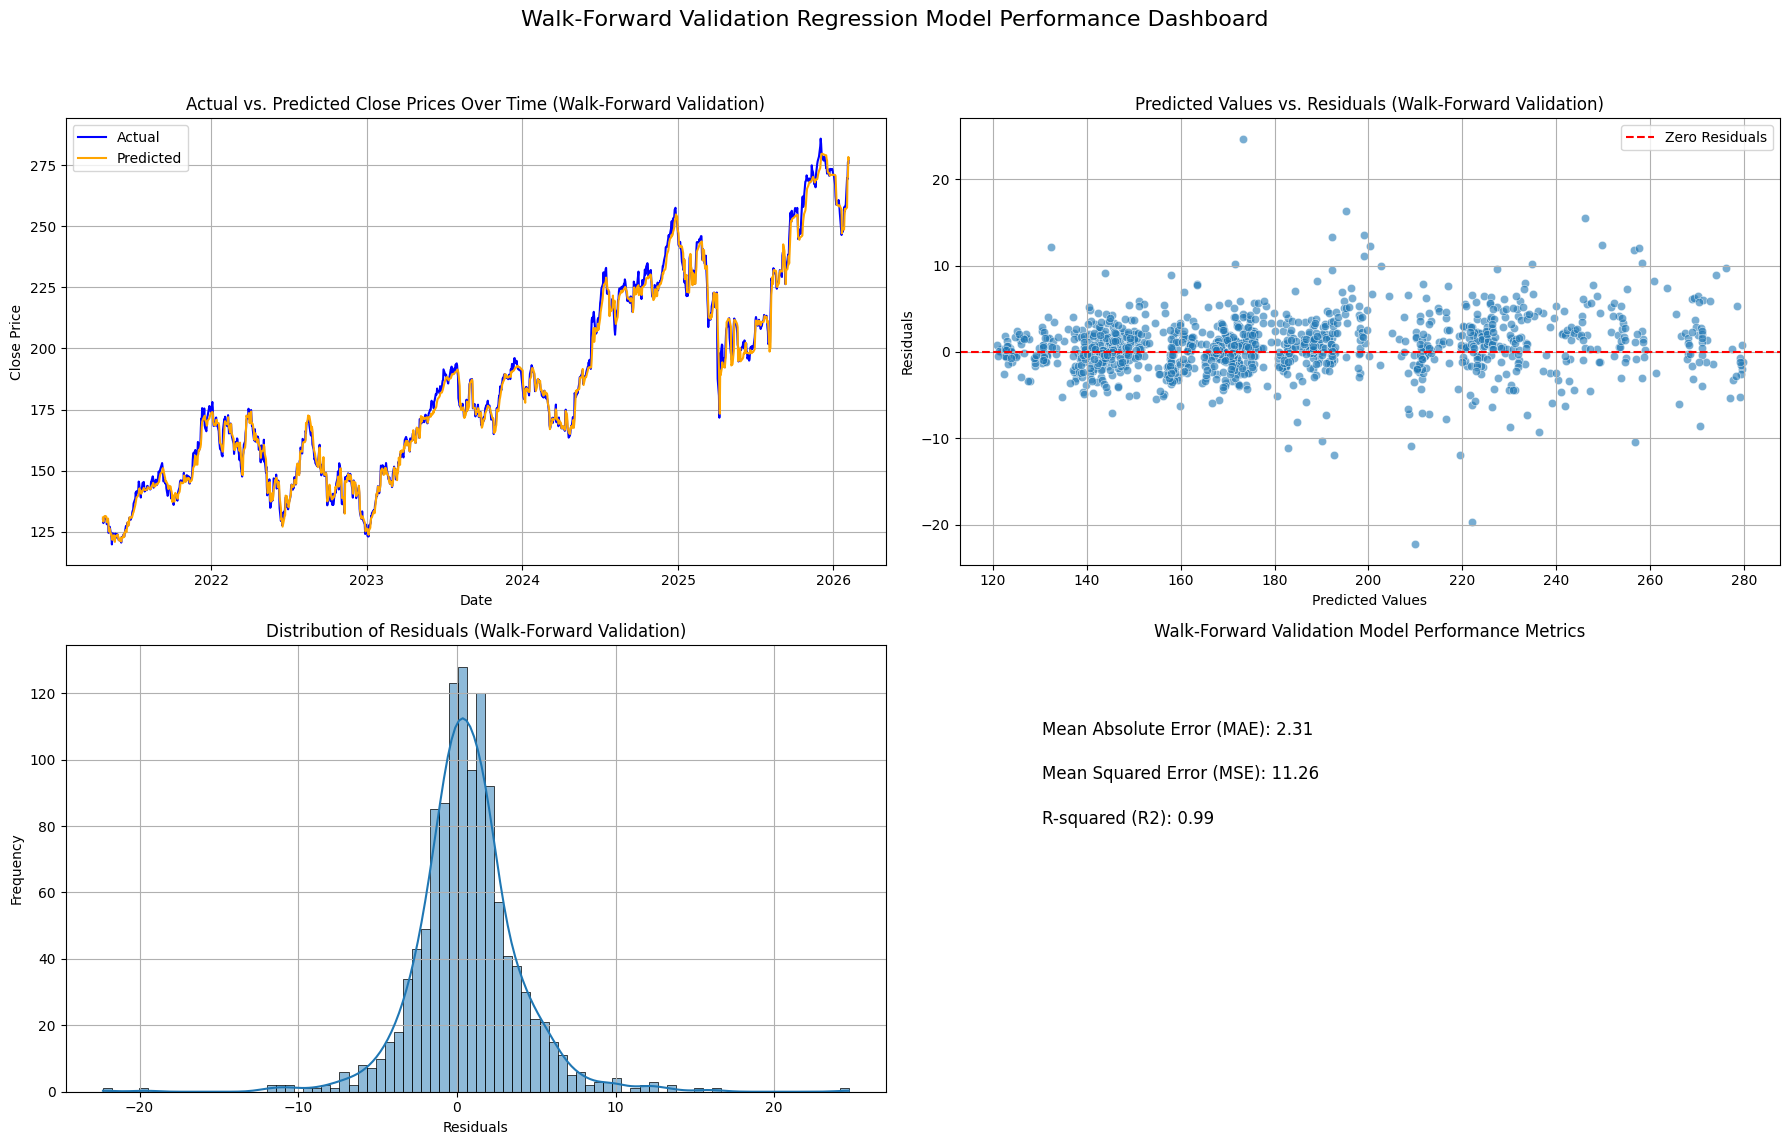

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df_wf = pd.DataFrame({
    'Actual': walk_forward_actuals_series,
    'Predicted': walk_forward_predictions_series
}, index=walk_forward_dates)

results_df_wf['Residuals'] = results_df_wf['Actual'] - results_df_wf['Predicted']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Walk-Forward Validation Regression Model Performance Dashboard', fontsize=16)

# Plot 1: Actual vs. Predicted Close Prices
sns.lineplot(x=results_df_wf.index, y='Actual', data=results_df_wf, label='Actual', color='blue', ax=axes[0, 0])
sns.lineplot(x=results_df_wf.index, y='Predicted', data=results_df_wf, label='Predicted', color='orange', ax=axes[0, 0])
axes[0, 0].set_title('Actual vs. Predicted Close Prices Over Time (Walk-Forward Validation)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Close Price')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Predicted Values vs. Residuals
sns.scatterplot(x='Predicted', y='Residuals', data=results_df_wf, ax=axes[0, 1], alpha=0.6)
axes[0, 1].axhline(y=0, color='red', linestyle='--', label='Zero Residuals')
axes[0, 1].set_title('Predicted Values vs. Residuals (Walk-Forward Validation)')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Histogram of Residuals
sns.histplot(results_df_wf['Residuals'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Residuals (Walk-Forward Validation)')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True)
axes[1, 1].text(0.1, 0.8, f'Mean Absolute Error (MAE): {mae_wf:.2f}', fontsize=12)
axes[1, 1].text(0.1, 0.7, f'Mean Squared Error (MSE): {mse_wf:.2f}', fontsize=12)
axes[1, 1].text(0.1, 0.6, f'R-squared (R2): {r2_wf:.2f}', fontsize=12)
axes[1, 1].set_title('Walk-Forward Validation Model Performance Metrics')
axes[1, 1].axis('off') # Hide axes for text display

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()